In [14]:
# import os, random, warnings
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import joblib
# warnings.filterwarnings("ignore")
# os.makedirs("models", exist_ok=True)

# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"PyTorch  : {torch.__version__}")
# print(f"Device   : {DEVICE}")
# print(f"NumPy    : {np.__version__}")
# print("Environment ready ✓")

In [15]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Environment ready")

TensorFlow: 2.18.0
Environment ready


In [16]:
df = pd.read_csv("data/03_panel_instability.csv")
df = df.sort_values(["COUNTRY", "YEAR"]).copy()

base_feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index_lag1",
]

volatility_cols = [
    col for col in [
        "GDP_Growth_rollstd3",
        "Inflation_rollstd3",
        "Exports_rollstd3",
        "Imports_rollstd3",
        "Fiscal_Balance_rollstd3",
        "Current_Account_rollstd3",
        "Debt_rollstd3",
        "Revenue_rollstd3",
        "Expenditure_rollstd3",
        "Savings_rollstd3",
        "Investment_rollstd3",
    ]
    if col in df.columns
]

# Same useful country-history features used in improved ML layer
df["Country_GDP_Mean_lag1"] = (
    df.groupby("COUNTRY")["GDP_Growth"]
    .transform(lambda x: x.shift(1).expanding(min_periods=3).mean())
)

df["Country_GDP_Std_lag1"] = (
    df.groupby("COUNTRY")["GDP_Growth"]
    .transform(lambda x: x.shift(1).expanding(min_periods=3).std())
)

df["GDP_vs_Country_Mean_lag1"] = (
    df["GDP_Growth_lag1"] - df["Country_GDP_Mean_lag1"]
)

df["Year_Trend"] = df["YEAR"] - df["YEAR"].min()

country_history_cols = [
    "Country_GDP_Mean_lag1",
    "Country_GDP_Std_lag1",
    "GDP_vs_Country_Mean_lag1",
    "Year_Trend",
]

feature_cols = (
    base_feature_cols
    + volatility_cols
    + country_history_cols
)

df_model = df.dropna(
    subset=feature_cols + ["GDP_Growth"]
).copy()

print(f"Loaded: {df_model.shape}")
print(f"Countries: {df_model['COUNTRY'].nunique()}")
print(f"Years: {df_model['YEAR'].min()}-{df_model['YEAR'].max()}")
print(f"Features: {len(feature_cols)}")

Loaded: (4632, 120)
Countries: 175
Years: 2000-2026
Features: 28


In [17]:
SEQ_LEN = 3

def build_sequences(data, feature_cols, target_col, seq_len=5):
    X_seq = []
    y_seq = []
    meta = []

    for country, grp in data.groupby("COUNTRY"):
        grp = grp.sort_values("YEAR").reset_index(drop=True)

        X_values = grp[feature_cols].to_numpy()
        y_values = grp[target_col].to_numpy()
        years = grp["YEAR"].to_numpy()

        for i in range(seq_len - 1, len(grp)):
            X_seq.append(
                X_values[i - seq_len + 1:i + 1]
            )

            y_seq.append(y_values[i])

            meta.append({
                "COUNTRY": country,
                "YEAR": years[i],
            })

    return (
        np.array(X_seq),
        np.array(y_seq),
        pd.DataFrame(meta),
    )


X_all, y_all, meta_all = build_sequences(
    df_model,
    feature_cols,
    "GDP_Growth",
    seq_len=SEQ_LEN,
)

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print(meta_all.head())

X_all: (4282, 3, 28)
y_all: (4282,)
                            COUNTRY  YEAR
0  Afghanistan, Islamic Republic of  2010
1  Afghanistan, Islamic Republic of  2011
2  Afghanistan, Islamic Republic of  2012
3  Afghanistan, Islamic Republic of  2013
4  Afghanistan, Islamic Republic of  2014


In [18]:
train_mask = meta_all["YEAR"] <= 2019
covid_mask = meta_all["YEAR"].isin([2020, 2021])
test_mask = meta_all["YEAR"].isin([2022, 2023])
projection_mask = meta_all["YEAR"].isin([2024, 2025, 2026])

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_covid = X_all[covid_mask]
y_covid = y_all[covid_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]
meta_test = meta_all[test_mask].reset_index(drop=True)

X_projection = X_all[projection_mask]
meta_projection = meta_all[projection_mask].reset_index(drop=True)

print(f"Train: {X_train.shape}")
print(f"COVID stress: {X_covid.shape}")
print(f"Observed test 2022-23: {X_test.shape}")
print(f"Projection 2024-26: {X_projection.shape}")

Train: (3077, 3, 28)
COVID stress: (346, 3, 28)
Observed test 2022-23: (346, 3, 28)
Projection 2024-26: (513, 3, 28)


In [19]:
n_features = X_train.shape[2]

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
scaler.fit(X_train_2d)

def scale_sequences(X, scaler):
    original_shape = X.shape
    X_2d = X.reshape(-1, original_shape[2])
    X_scaled = scaler.transform(X_2d)
    return X_scaled.reshape(original_shape)

X_train_sc = scale_sequences(X_train, scaler)
X_covid_sc = scale_sequences(X_covid, scaler)
X_test_sc = scale_sequences(X_test, scaler)
X_projection_sc = scale_sequences(X_projection, scaler)

In [20]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# Time-based validation
# Train: <= 2017
# Validation: 2018-2019
# ------------------------------------------------------------

val_mask = meta_all["YEAR"].isin([2018, 2019])
train_lstm_mask = meta_all["YEAR"] <= 2017

X_lstm_train = X_all[train_lstm_mask]
y_lstm_train = y_all[train_lstm_mask]

X_lstm_val = X_all[val_mask]
y_lstm_val = y_all[val_mask]

# ------------------------------------------------------------
# Scale X using training only
# ------------------------------------------------------------

x_scaler = StandardScaler()
x_scaler.fit(
    X_lstm_train.reshape(-1, n_features)
)

X_lstm_train_sc = scale_sequences(X_lstm_train, x_scaler)
X_lstm_val_sc = scale_sequences(X_lstm_val, x_scaler)
X_test_sc = scale_sequences(X_test, x_scaler)
X_covid_sc = scale_sequences(X_covid, x_scaler)
X_projection_sc = scale_sequences(X_projection, x_scaler)

# ------------------------------------------------------------
# Scale y target also
# ------------------------------------------------------------

y_scaler = StandardScaler()

y_lstm_train_sc = y_scaler.fit_transform(
    y_lstm_train.reshape(-1, 1)
).flatten()

y_lstm_val_sc = y_scaler.transform(
    y_lstm_val.reshape(-1, 1)
).flatten()

# ------------------------------------------------------------
# LSTM model
# ------------------------------------------------------------

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model = Sequential([
    LSTM(
        48,
        input_shape=(SEQ_LEN, n_features),
        return_sequences=False,
    ),
    Dropout(0.30),
    Dense(24, activation="relu"),
    Dropout(0.15),
    Dense(1),
])

model.compile(
    optimizer=Adam(learning_rate=0.0007),
    loss=Huber(delta=1.0),
    metrics=["mae"],
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-5,
)

history = model.fit(
    X_lstm_train_sc,
    y_lstm_train_sc,
    validation_data=(X_lstm_val_sc, y_lstm_val_sc),
    epochs=250,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

model.save("models/lstm_gdp_growth.keras")

print("Saved: models/lstm_gdp_growth.keras")


Epoch 1/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2738 - mae: 0.5708 - val_loss: 0.1371 - val_mae: 0.3763 - learning_rate: 7.0000e-04
Epoch 2/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2500 - mae: 0.5349 - val_loss: 0.1321 - val_mae: 0.3678 - learning_rate: 7.0000e-04
Epoch 3/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2438 - mae: 0.5252 - val_loss: 0.1289 - val_mae: 0.3628 - learning_rate: 7.0000e-04
Epoch 4/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2383 - mae: 0.5169 - val_loss: 0.1270 - val_mae: 0.3598 - learning_rate: 7.0000e-04
Epoch 5/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2356 - mae: 0.5117 - val_loss: 0.1240 - val_mae: 0.3536 - learning_rate: 7.0000e-04
Epoch 6/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2345 - mae: 0.5107 - val_loss: 0.1211 - val_mae: 0.3486 - learning_rate: 7.0000e-04
Epoch 7/250
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2298 - mae: 0.5065 - val_loss: 0.1196 - val_mae: 0.3473 - learnin

In [21]:
# ------------------------------------------------------------
# Validation-based calibration
# Fit correction only on validation period 2018-2019
# ------------------------------------------------------------

val_pred_scaled = model.predict(X_lstm_val_sc).flatten()

val_pred = y_scaler.inverse_transform(
    val_pred_scaled.reshape(-1, 1)
).flatten()

# Linear calibration:
# actual = a + b * predicted
calibration_slope, calibration_intercept = np.polyfit(
    val_pred,
    y_lstm_val,
    1,
)

print("Calibration intercept:", calibration_intercept)
print("Calibration slope:", calibration_slope)

def calibrate_predictions(pred):
    return calibration_intercept + calibration_slope * pred

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Calibration intercept: -1.3393213400183293
Calibration slope: 1.299922027137276


In [22]:
pred_test_calibrated = calibrate_predictions(pred_test)

In [23]:
def evaluate_regression(name, y_true, y_pred, period):
    return {
        "Model": name,
        "Period": period,
        "N": len(y_true),
        "RMSE": round(
            np.sqrt(mean_squared_error(y_true, y_pred)),
            3,
        ),
        "MAE": round(
            mean_absolute_error(y_true, y_pred),
            3,
        ),
        "R2": round(
            r2_score(y_true, y_pred),
            3,
        ),
        "Mean_Actual": round(float(np.mean(y_true)), 2),
        "Mean_Predicted": round(float(np.mean(y_pred)), 2),
        "Mean_Error": round(float(np.mean(y_true - y_pred)), 2),
    }


# ------------------------------------------------------------
# Predict and inverse-transform
# ------------------------------------------------------------

pred_test_scaled = model.predict(X_test_sc).flatten()

pred_test = y_scaler.inverse_transform(
    pred_test_scaled.reshape(-1, 1)
).flatten()

lstm_rows = []

lstm_rows.append(
    evaluate_regression(
        "LSTM calibrated",
        y_test,
        pred_test_calibrated,
        "Observed test (2022-23)",
    )
)

for year in [2022, 2023]:
    mask = meta_test["YEAR"] == year

    lstm_rows.append(
        evaluate_regression(
            "LSTM calibrated",
            y_test[mask],
            pred_test_calibrated[mask],
            f"Year {year}",
        )
    )

lstm_results_df = pd.DataFrame(lstm_rows)

lstm_results_df.to_csv(
    "data/layer3_lstm_results.csv",
    index=False,
)

display(lstm_results_df)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,LSTM calibrated,Observed test (2022-23),346,5.022,2.829,0.136,3.81,2.95,0.86
1,LSTM calibrated,Year 2022,173,6.184,3.304,0.086,4.51,3.21,1.30
2,LSTM calibrated,Year 2023,173,3.492,2.355,0.217,3.12,2.69,0.42


In [24]:
pred_covid_scaled = model.predict(X_covid_sc).flatten()

pred_covid = y_scaler.inverse_transform(
    pred_covid_scaled.reshape(-1, 1)
).flatten()

lstm_covid_df = pd.DataFrame([
    evaluate_regression(
        "LSTM",
        y_covid,
        pred_covid,
        "COVID stress test (2020-21)",
    )
])

lstm_covid_df.to_csv(
    "data/layer3_lstm_covid_stress.csv",
    index=False,
)

display(lstm_covid_df)
print("Saved: data/layer3_lstm_covid_stress.csv")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,LSTM,COVID stress test (2020-21),346,8.863,6.656,-0.13,0.76,2.59,-1.83


Saved: data/layer3_lstm_covid_stress.csv


In [25]:
pred_projection_scaled = model.predict(X_projection_sc).flatten()

pred_projection = y_scaler.inverse_transform(
    pred_projection_scaled.reshape(-1, 1)
).flatten()

lstm_projection_df = meta_projection.copy()
lstm_projection_df["LSTM_Forecast"] = pred_projection

lstm_projection_df.to_csv(
    "data/layer3_lstm_forecasts_2024_2026.csv",
    index=False,
)

display(lstm_projection_df.head())
print("Saved: data/layer3_lstm_forecasts_2024_2026.csv")

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,COUNTRY,YEAR,LSTM_Forecast
0,"Afghanistan, Islamic Republic of",2024,0.641401
1,"Afghanistan, Islamic Republic of",2025,-1.129451
2,Albania,2024,4.365195
3,Albania,2025,4.634110
4,Albania,2026,4.542422


Saved: data/layer3_lstm_forecasts_2024_2026.csv


In [26]:
layer2b_best = pd.read_csv(r"data/layer2b_best_result.csv")
lstm_results = pd.read_csv(r"data/layer3_lstm_results.csv")

lstm_main = lstm_results[
    lstm_results["Period"] == "Observed test (2022-23)"
].copy()

comparison = pd.DataFrame([
    {
        "Layer": "Layer 2b ML",
        "Model": layer2b_best.loc[0, "Model"],
        "RMSE": layer2b_best.loc[0, "RMSE"],
        "MAE": layer2b_best.loc[0, "MAE"],
        "R2": layer2b_best.loc[0, "R2"],
    },
    {
        "Layer": "Layer 3 LSTM",
        "Model": "LSTM",
        "RMSE": lstm_main.iloc[0]["RMSE"],
        "MAE": lstm_main.iloc[0]["MAE"],
        "R2": lstm_main.iloc[0]["R2"],
    },
])

comparison = comparison.sort_values("RMSE")

comparison.to_csv(
    "data/layer2b_vs_lstm_comparison.csv",
    index=False,
)

display(comparison)
print("Saved: data/layer2b_vs_lstm_comparison.csv")

,Layer,Model,RMSE,MAE,R2
0,Layer 2b ML,Random Forest,4.709,2.631,0.241
1,Layer 3 LSTM,LSTM,5.022,2.829,0.136


Saved: data/layer2b_vs_lstm_comparison.csv


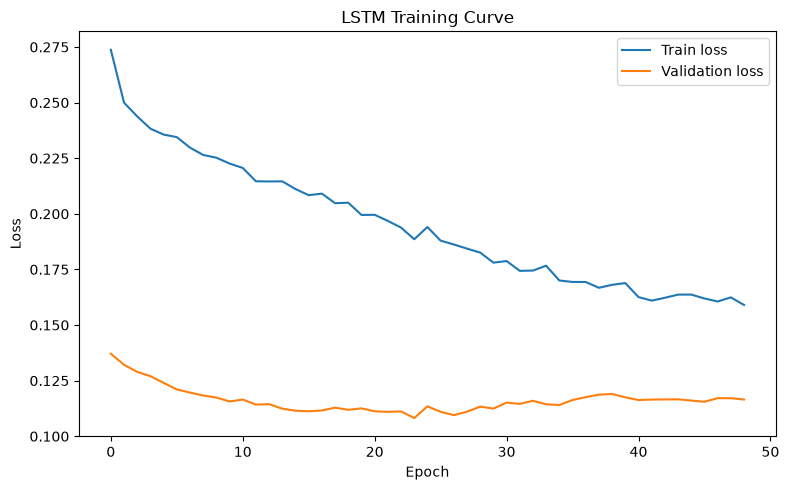

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig("layer3_lstm_training_curve.png", dpi=150)
plt.show()

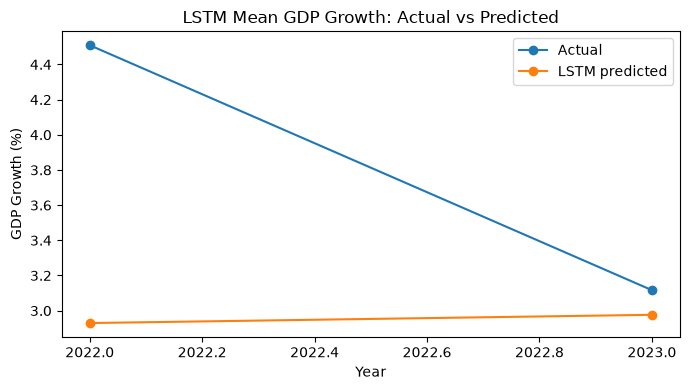

In [28]:
plot_df = meta_test.copy()
plot_df["Actual"] = y_test
plot_df["Predicted"] = pred_test
plot_df["Error"] = plot_df["Actual"] - plot_df["Predicted"]

year_summary = (
    plot_df
    .groupby("YEAR")[["Actual", "Predicted"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

plt.plot(year_summary["YEAR"], year_summary["Actual"], marker="o", label="Actual")
plt.plot(year_summary["YEAR"], year_summary["Predicted"], marker="o", label="LSTM predicted")

plt.title("LSTM Mean GDP Growth: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.tight_layout()

plt.savefig("layer3_lstm_actual_vs_predicted.png", dpi=150)
plt.show()

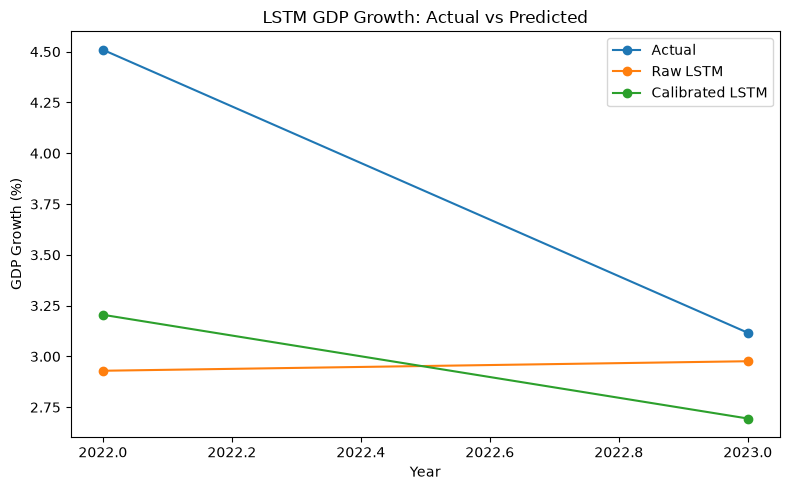

In [29]:
plot_df = meta_test.copy()
plot_df["Actual"] = y_test
plot_df["Predicted"] = pred_test
plot_df["Predicted_Calibrated"] = pred_test_calibrated

year_summary = (
    plot_df
    .groupby("YEAR")[["Actual", "Predicted", "Predicted_Calibrated"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    year_summary["YEAR"],
    year_summary["Actual"],
    marker="o",
    label="Actual",
)

plt.plot(
    year_summary["YEAR"],
    year_summary["Predicted"],
    marker="o",
    label="Raw LSTM",
)

plt.plot(
    year_summary["YEAR"],
    year_summary["Predicted_Calibrated"],
    marker="o",
    label="Calibrated LSTM",
)

plt.title("LSTM GDP Growth: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.tight_layout()

plt.savefig("layer3_lstm_actual_vs_predicted_calibrated.png", dpi=150)
plt.show()

The LSTM captures broad temporal direction after calibration, but it fails to accurately reproduce the magnitude of GDP growth changes. This suggests that deep sequence learning is less effective for this annual macro-panel dataset than tree-based ML models.

The LSTM model produced smoothed predictions that were biased toward the mean. In 2022, it substantially underestimated average GDP growth, while in 2023 it was closer to the observed value. After validation-based calibration, the model captured the downward movement from 2022 to 2023 more clearly, but the gap between actual and predicted values remained. This indicates that the annual panel does not provide enough temporal depth for the LSTM to outperform tabular machine learning models.